I created a separate notebook for collecting ground truth TTS audio clips and analyzing them to create my duration predictor.

In [6]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

IMAGES_DIR = Path.cwd() / "images"
IMAGES_DIR.mkdir(exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"IMAGES_DIR:   {IMAGES_DIR}")

PROJECT_ROOT: /Users/bkim/college/ai/foreign-whispers
IMAGES_DIR:   /Users/bkim/college/ai/foreign-whispers/notebooks/alignment_integration/images


In [7]:
en_dir = PROJECT_ROOT / "pipeline_data" / "api" / "transcriptions" / "whisper"
es_dir = PROJECT_ROOT / "pipeline_data" / "api" / "translations" / "argos"

en_files = sorted(en_dir.glob("*.json"))
es_files = sorted(es_dir.glob("*.json"))

assert en_files, f"No EN transcripts found in {en_dir}"
assert es_files, f"No ES translations found in {es_dir}"

en_path = en_files[1]
es_path = es_files[1]

with open(en_path) as f:
    en_transcript = json.load(f)
with open(es_path) as f:
    es_transcript = json.load(f)

print(f"EN transcript: {en_path.name}  ({len(en_transcript.get('segments', []))} segments)")
print(f"ES transcript: {es_path.name}  ({len(es_transcript.get('segments', []))} segments)")

EN transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)
ES transcript: Strait of Hormuz disruption threatens to shake global economy.json  (98 segments)


In [11]:
import os
from pathlib import Path
import wave
import io

import requests
from IPython.display import Audio

CHATTERBOX_API_URL = "https://njzzckai6awons-5123.proxy.runpod.net"

h = requests.get(f"{CHATTERBOX_API_URL}/health", timeout=30)
print("GET /health →", h.status_code, h.text[:300])

def generate_audio(text: str) -> bytes:
    payload = {"input": text, "response_format": "wav"}
    r = requests.post(
        f"{CHATTERBOX_API_URL}/v1/audio/speech",
        json=payload,
        timeout=(10, 180),
    )
    return r.content

def get_audio_duration(audio_bytes: bytes) -> float:
    with wave.open(io.BytesIO(audio_bytes), "rb") as wav_file:
        return wav_file.getnframes() / wav_file.getframerate()

GET /health → 200 {"status":"healthy","model_loaded":true,"device":"cuda","config":{"max_chunk_length":280,"max_total_length":3000,"voice_sample_path":"/app/voice-sample.mp3","default_exaggeration":0.5,"default_cfg_weight":0.5,"default_temperature":0.8},"memory_info":{"cpu_memory_mb":2833.640625,"cpu_memory_percent":


In [ ]:
for seg in es_transcript["segments"]:
    audio_bytes = generate_audio(seg["text"])
    duration = get_audio_duration(audio_bytes)

    seg["en_duration"] = seg["end"] - seg["start"]
    seg["es_duration"] = duration

    with open("es_transcript_out.json", "w", encoding="utf-8") as f:
        json.dump(es_transcript, f, ensure_ascii=False, indent=2)

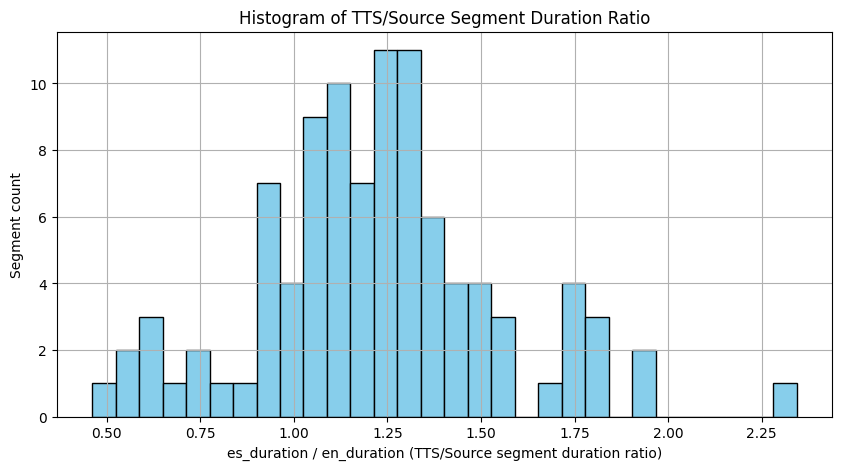

In [14]:
import matplotlib.pyplot as plt
import numpy as np

en_durations = [seg["end"] - seg["start"] for seg in es_transcript["segments"]]
es_durations = [seg.get("es_duration", None) for seg in es_transcript["segments"]]

# Only compute ratios when both durations are available and es_duration is not None or 0
ratios = [
    es / en if en > 0 and es is not None and es > 0 else None
    for en, es in zip(en_durations, es_durations)
]

# Filter out None values
ratios = [r for r in ratios if r is not None]

plt.figure(figsize=(10, 5))
plt.hist(ratios, bins=30, color='skyblue', edgecolor='black')
plt.xlabel("es_duration / en_duration (TTS/Source segment duration ratio)")
plt.ylabel("Segment count")
plt.title("Histogram of TTS/Source Segment Duration Ratio")
plt.grid(True)
plt.show()

In [20]:
!python -m pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/01/18/d154dc1638803adf987910cdd07097d9c526663a55666a97c124d09fb96a/scikit_learn-1.8.0-cp311-cp311-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for scipy>=1.10.0 from https://files.pythonhosted.org/packages/6d/ee/18146b7757ed4976276b9c9819108adbc73c5aad636e5353e20746b73069/scipy-1.17.1-cp311-cp311-macosx_14_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.8 MB/s eta 0:00:00
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 39.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 39.8 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update,

In [22]:
# Linear regression (scikit-learn): predict es_duration from simple text stats
import numpy as np
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Prefer in-memory transcript if TTS durations are present; else load saved JSON
_segs = es_transcript.get("segments", [])
if _segs and all("es_duration" in s for s in _segs):
    segments = _segs
else:
    _out = Path.cwd() / "es_transcript_out.json"
    if not _out.exists():
        raise FileNotFoundError("run tts first")
    with open(_out, encoding="utf-8") as f:
        segments = json.load(f)["segments"]

texts = [s["text"].strip() for s in segments]

# Features: character count, word count (sklearn adds intercept by default)
X = np.array([[len(t), len(t.split()) if t else 0] for t in texts], dtype=float)
y = np.array([float(s["es_duration"]) for s in segments], dtype=float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Features: n_chars, n_words (LinearRegression fits an intercept)")
print("coef_ (per char, per word):", model.coef_)
print("intercept_:", model.intercept_)
print()
print("Train — R²:", f"{r2_score(y_train, y_pred_train):.4f}", "  MAE:", f"{mean_absolute_error(y_train, y_pred_train):.4f}s")
print("Test  — R²:", f"{r2_score(y_test, y_pred_test):.4f}", "  MAE:", f"{mean_absolute_error(y_test, y_pred_test):.4f}s")

Features: n_chars, n_words (LinearRegression fits an intercept)
coef_ (per char, per word): [0.06094574 0.06799571]
intercept_: 0.3466867127865596

Train — R²: 0.9728   MAE: 0.2939s
Test  — R²: 0.9490   MAE: 0.3964s


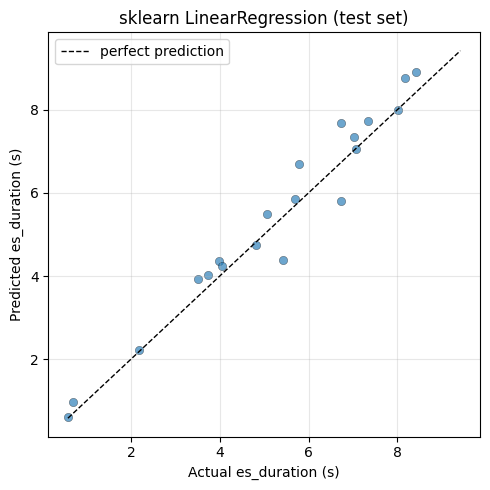

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred_test, alpha=0.65, edgecolors="k", linewidths=0.3)
lo, hi = float(y.min()), float(y.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="perfect prediction")
ax.set_xlabel("Actual es_duration (s)")
ax.set_ylabel("Predicted es_duration (s)")
ax.set_title("sklearn LinearRegression (test set)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()